<a href="https://colab.research.google.com/github/realyams/medical/blob/data/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install datasets Pillow pandas

**chargement du dataset**

In [5]:
from datasets import load_dataset

dataset = load_dataset("eltorio/ROCO-radiology", split="train")
print(f"Nombre d'exemples : {len(dataset)}")
print(dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

data/train-00000-of-00026.parquet:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/65423 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8175 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8176 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/26 [00:00<?, ?it/s]

Nombre d'exemples : 65423
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=704x704 at 0x7C7E6616B9E0>, 'image_id': 'ROCO_00002', 'caption': ' Computed tomography scan in axial view showing obliteration of the left maxillary sinus\n'}


**explorer les donnees**

In [6]:
import pandas as pd

# Convertir en dataframe pour mieux visualiser
df = pd.DataFrame(dataset.remove_columns("image"))

print(df.shape)
print(df.head(5))
print(f"\nLongueur moyenne des captions : {df['caption'].str.len().mean():.0f} caractères")

(65423, 2)
     image_id                                            caption
0  ROCO_00002   Computed tomography scan in axial view showin...
1  ROCO_00003   Bacterial contamination occurred after comple...
2  ROCO_00004   The patient had residual paralysis of the han...
3  ROCO_00005    Panoramic radiograph after immediate loading.\n
4  ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...

Longueur moyenne des captions : 140 caractères


**nettoyage des donnees**

In [7]:
# Nettoyer les captions (enlever espaces et sauts de ligne)
df['caption'] = df['caption'].str.strip()

# Garder seulement les captions assez longues (plus de 50 caractères)
df_clean = df[df['caption'].str.len() > 50]

print(f"Avant nettoyage : {len(df)} exemples")
print(f"Après nettoyage : {len(df_clean)} exemples")
print(f"Supprimés : {len(df) - len(df_clean)} exemples")

Avant nettoyage : 65423 exemples
Après nettoyage : 57243 exemples
Supprimés : 8180 exemples


**echantillonage**

In [8]:
# Prendre 500 exemples aléatoires
df_sample = df_clean.sample(500, random_state=42)

# Réinitialiser l'index
df_sample = df_sample.reset_index(drop=True)

print(f"Dataset final : {len(df_sample)} exemples")
print(df_sample.head(3))

Dataset final : 500 exemples
     image_id                                            caption
0  ROCO_34522  The same patient in Fig. 1 with bilateral pleu...
1  ROCO_03054  Immediate postoperative radiograph of pelvis w...
2  ROCO_08168  CT quantification of hemoperitoneum.The depth ...


**format JSON**

In [9]:
import json

data = []
for _, row in df_sample.iterrows():
    exemple = {
        "instruction": "Analyze this medical image and describe the clinical observations.",
        "input": "",
        "image_id": row['image_id'],
        "output": row['caption']
    }
    data.append(exemple)

# Sauvegarder
with open("dataset.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"✅ dataset.json créé avec {len(data)} exemples !")

# Vérifier les 2 premiers
for ex in data[:2]:
    print("\n---")
    print(ex)

✅ dataset.json créé avec 500 exemples !

---
{'instruction': 'Analyze this medical image and describe the clinical observations.', 'input': '', 'image_id': 'ROCO_34522', 'output': 'The same patient in Fig.\xa01 with bilateral pleural effusion is seen in CT scanning of the chest'}

---
{'instruction': 'Analyze this medical image and describe the clinical observations.', 'input': '', 'image_id': 'ROCO_03054', 'output': 'Immediate postoperative radiograph of pelvis with bilateral hips anteroposterior view following the second stage reconstruction illustrating a well-constructed acetabular and femoral defect with cup-cage construct and allograft prosthesis composite, anatomic restoration of the hip center, and equalization of limb length. The inferior flange of the cage had cut through the ischium'}


In [10]:
# Recharger et vérifier
with open("dataset.json", "r", encoding="utf-8") as f:
    data_check = json.load(f)

print(f"Nombre d'exemples dans le fichier : {len(data_check)}")
print(f"Clés disponibles : {list(data_check[0].keys())}")
print(f"\nPremier exemple :")
print(json.dumps(data_check[0], indent=2, ensure_ascii=False))

Nombre d'exemples dans le fichier : 500
Clés disponibles : ['instruction', 'input', 'image_id', 'output']

Premier exemple :
{
  "instruction": "Analyze this medical image and describe the clinical observations.",
  "input": "",
  "image_id": "ROCO_34522",
  "output": "The same patient in Fig. 1 with bilateral pleural effusion is seen in CT scanning of the chest"
}


In [11]:
from google.colab import files
files.download("dataset.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
df.head()

,image_id,caption
0,ROCO_00002,Computed tomography scan in axial view showing...
1,ROCO_00003,Bacterial contamination occurred after complet...
2,ROCO_00004,The patient had residual paralysis of the hand...
3,ROCO_00005,Panoramic radiograph after immediate loading.
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at th...


In [13]:
from sklearn.model_selection import train_test_split

# First split : 80% train, 20% temp
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)

# Second split : temp → 50% val, 50% test
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"✅ Train : {len(train_data)} examples (80%)")
print(f"✅ Val   : {len(val_data)} examples (10%)")
print(f"✅ Test  : {len(test_data)} examples (10%)")

✅ Train : 400 examples (80%)
✅ Val   : 50 examples (10%)
✅ Test  : 50 examples (10%)


In [14]:
# Save train.json
with open("train.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

# Save val.json
with open("val.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

# Save test.json
with open("test.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, ensure_ascii=False, indent=2)

print("✅ train.json saved !")
print("✅ val.json saved !")
print("✅ test.json saved !")

✅ train.json saved !
✅ val.json saved !
✅ test.json saved !


In [18]:
from google.colab import files
files.download("test.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
print(df.columns.tolist())
print(df.head(2))

['image_id', 'caption']
     image_id                                            caption
0  ROCO_00002  Computed tomography scan in axial view showing...
1  ROCO_00003  Bacterial contamination occurred after complet...


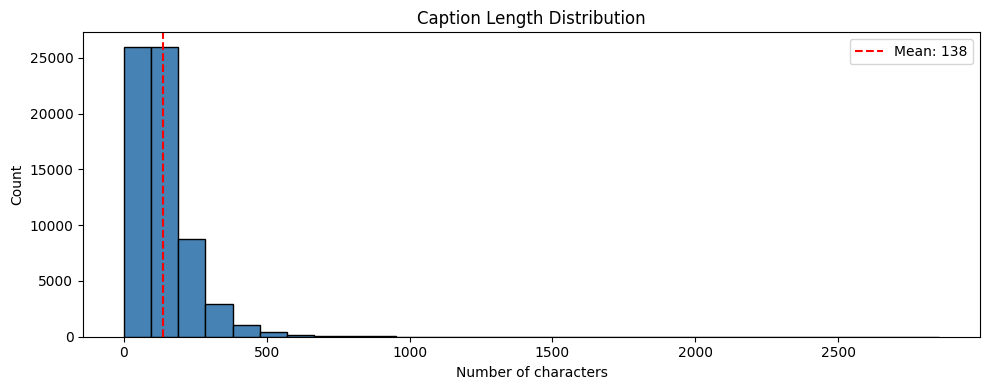

In [23]:
import matplotlib.pyplot as plt

# Add the column
df['caption_length'] = df['caption'].str.len()

plt.figure(figsize=(10, 4))
plt.hist(df['caption_length'], bins=30, color='steelblue', edgecolor='black')
plt.title('Caption Length Distribution')
plt.xlabel('Number of characters')
plt.ylabel('Count')
plt.axvline(df['caption_length'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["caption_length"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

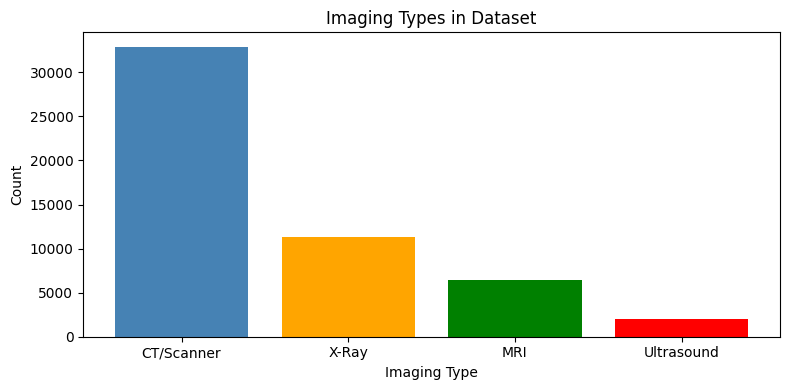

CT/Scanner      : 32897 examples (50.3%)
X-Ray           : 11373 examples (17.4%)
MRI             : 6463 examples (9.9%)
Ultrasound      : 2051 examples (3.1%)


In [24]:
keywords = {
    'CT/Scanner'  : ['CT', 'computed tomography', 'scan'],
    'X-Ray'       : ['x-ray', 'radiograph', 'plain film'],
    'MRI'         : ['MRI', 'magnetic resonance'],
    'Ultrasound'  : ['ultrasound', 'echography'],
}

counts = {}
for name, words in keywords.items():
    count = df['caption'].str.contains('|'.join(words), case=False).sum()
    counts[name] = count

# Plot
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=['steelblue', 'orange', 'green', 'red'])
plt.title('Imaging Types in Dataset')
plt.xlabel('Imaging Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

for name, count in counts.items():
    print(f"{name:15} : {count} examples ({count/len(df)*100:.1f}%)")

In [25]:
# Full dataset summary
print("=" * 50)
print("       DATASET QUALITY REPORT")
print("=" * 50)
print(f"\n📊 GENERAL STATS")
print(f"Total examples (clean)  : {len(df)}")
print(f"Average caption length  : {df['caption_length'].mean():.0f} chars")
print(f"Min caption length      : {df['caption_length'].min()} chars")
print(f"Max caption length      : {df['caption_length'].max()} chars")

print(f"\n🏥 IMAGING TYPES")
for name, count in counts.items():
    print(f"{name:15} : {count:5} ({count/len(df)*100:.1f}%)")

print(f"\n📁 SPLITS")
print(f"Train : 400 examples (80%)")
print(f"Val   :  50 examples (10%)")
print(f"Test  :  50 examples (10%)")

print("\n" + "=" * 50)
print("✅ Dataset ready for fine-tuning !")
print("=" * 50)

       DATASET QUALITY REPORT

📊 GENERAL STATS
Total examples (clean)  : 65423
Average caption length  : 138 chars
Min caption length      : 0 chars
Max caption length      : 2854 chars

🏥 IMAGING TYPES
CT/Scanner      : 32897 (50.3%)
X-Ray           : 11373 (17.4%)
MRI             :  6463 (9.9%)
Ultrasound      :  2051 (3.1%)

📁 SPLITS
Train : 400 examples (80%)
Val   :  50 examples (10%)
Test  :  50 examples (10%)

✅ Dataset ready for fine-tuning !
